In [11]:
import os
os.environ["QT_QPA_PLATFORM"] = "xcb"
import cv2


img = cv2.imread('../datasets/lm.jpg', cv2.IMREAD_COLOR)
resized_img=cv2.resize(img,(300,300),interpolation=cv2.INTER_LINEAR)
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

cv2.imshow(img)
cv2.imshow(resized_img)
cv2.imshow('Grayscale Image', gray_img)

cv2.waitKey(0)
cv2.destroyAllWindows()
    

error: OpenCV(4.13.0) :-1: error: (-5:Bad argument) in function 'imshow'
> Overload resolution failed:
>  - imshow() missing required argument 'mat' (pos 2)
>  - imshow() missing required argument 'mat' (pos 2)
>  - imshow() missing required argument 'mat' (pos 2)


In [12]:
import os
os.environ["QT_QPA_PLATFORM"] = "xcb" # Fixes your Wayland/Qt error
import cv2

# Load the image
img = cv2.imread('../datasets/lm.jpg')
(h, w) = img.shape[:2]

# 1. Define the center of the image
center = (w // 2, h // 2)

# 2. Generate the rotation matrix
# Arguments: (center, angle_in_degrees, scale)
# Positive angle = Counter-clockwise rotation
M = cv2.getRotationMatrix2D(center, -30, 1.0) 

# 3. Apply the affine transformation
# Note: (w, h) is the size of the output image
rotated_img = cv2.warpAffine(img, M, (w, h))

# Display the result
cv2.imshow('Rotated Image', rotated_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

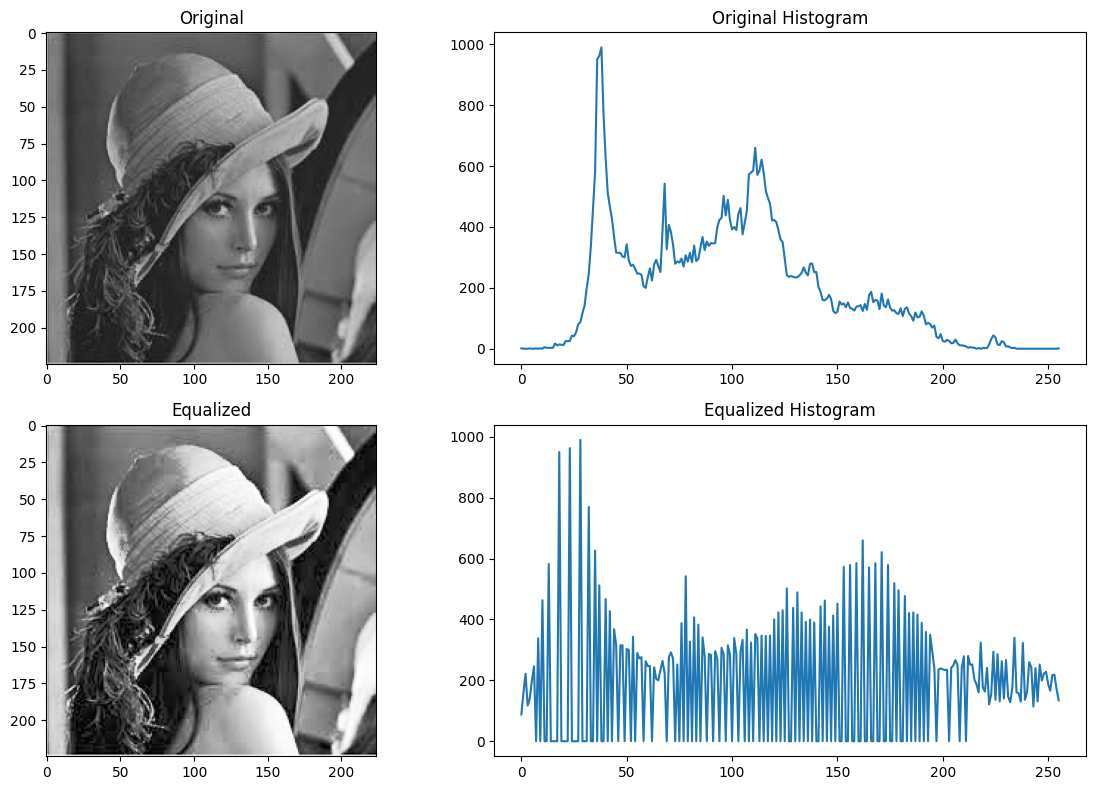

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load image and convert to grayscale
img = cv2.imread('../datasets/lm.jpg', cv2.IMREAD_GRAYSCALE)

# 2. Perform Histogram Equalization
equ = cv2.equalizeHist(img)

# 3. Calculate Histograms
# [img], [0] for grayscale channel, None for mask, [256] bins, [0, 256] range
hist_orig = cv2.calcHist([img], [0], None, [256], [0, 256])
hist_equ = cv2.calcHist([equ], [0], None, [256], [0, 256])

# 4. Visualization
plt.figure(figsize=(12, 8))

# Original Image & Histogram
plt.subplot(2, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original')
plt.subplot(2, 2, 2); plt.plot(hist_orig); plt.title('Original Histogram')

# Equalized Image & Histogram
plt.subplot(2, 2, 3); plt.imshow(equ, cmap='gray'); plt.title('Equalized')
plt.subplot(2, 2, 4); plt.plot(hist_equ); plt.title('Equalized Histogram')

plt.tight_layout()
plt.show()

In [32]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("../datasets/lm.jpg", cv2.IMREAD_GRAYSCALE)
min_max_normalized = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)

mean, std_dev = cv2.meanStdDev(img)
z_score_normalized = (img - mean) / std_dev
z_score_normalized = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)

cv2.imshow("original image", img)
cv2.imshow("MinMax Normalised image", min_max_normalized.astype(np.uint8))
cv2.imshow("Z score normalised image", z_score_normalized.astype(np.uint8))

cv2.waitKey(0)
cv2.destroyAllWindows()

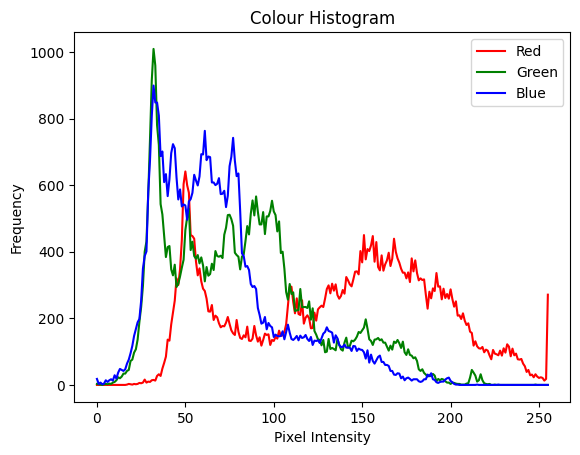

In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("../datasets/lm.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
channels = ('r', 'g', 'b' )
colors = ("Red", "Green", "Blue")

plt.figure()
plt.title("Colour Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

for i, color in enumerate(colors):
    hist = cv2.calcHist([image], [i], None, [256], [0,256])
    plt.plot(hist, label=color, color=channels[i])

plt.legend()
plt.show()

In [ ]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
_, thresh = cv2.threshold(blurred, 60, 255, cv2.THRESH_BINARY_INV)

contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

output_image = image.copy()

for contour in contours:
    area = cv2.contourArea(contour)
    if area > 100:  # Filter out small contours
        perimeter = cv2.arcLength(contour, True)
        if perimeter == 0:
            continue
        circularity = 4 * np.pi * (area / (perimeter * perimeter))

        # Check if the contour is somewhat circular
        if 0.7 < circularity < 1.3:  # Adjust this range as needed
            (x, y), radius = cv2.minEnclosingCircle(contour)
            center = (int(x), int(y))
            radius = int(radius)

            # Draw the enclosing circle and add text
            cv2.circle(output_image, center, radius, (0, 255, 0), 2) # Green circle
            cv2.putText(output_image, "Circle", (center[0] - 30, center[1]), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

cv2.imshow("image", output_image)